# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [69]:
import random

val_to_face = {
    1:  'Ace',
    11: 'Jack',
    12: 'Queen',
    13: 'King',
}

suits = ['Club', 'Spade', 'Heart', 'Diamond']
values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] #creates values to assign to the cards


class card:
    def __init__(self, suit, value):
        self.__suit = suit
        self.__value = value

    def get_suit(self):
        return self.__suit

    def get_value(self):
        return self.__value

    def blackjack_value(self):
        if self.__value in [11, 12, 13]:  # J, Q, K all count as 10
            return 10
        elif self.__value == 1:  # Ace is 11 until the hand logic decides otherwise
            return 11
        elif self.__value == 0:  # plastic cut card that doesn't have any game value
            return 0
        else:
            return self.__value

    def __repr__(self):
        if self.__suit == 'Plastic':
            return '[Plastic Cut Card]'
        display = val_to_face.get(self.__value, str(self.__value))
        return f'{display} of {self.__suit}s'


class deck:
    def __init__(self, cards, num_decks=6, penetration=0.75):
        self.__cards = cards
        self.__num_decks = num_decks
        self.__penetration = penetration  
        self.__needs_shuffle = False

    def __repr__(self):
        return repr(self.__cards)

    def shuffle(self):
        #removes the cut card from the deck before shuffling
        self.__cards = [c for c in self.__cards if c.get_suit() != 'Plastic']
        random.shuffle(self.__cards)
        self.__needs_shuffle = False

        total = len(self.__cards)
        # place the cut card so that (penetration)% of cards get dealt before hitting it
        cut_index = total - int(total * self.__penetration)
        # small random offset so the cut spot isn't always exact
        cut_index = max(1, min(total - 1, cut_index + random.randint(-5, 5)))

        self.__cards.insert(cut_index, card('Plastic', 0))
        return self

    def draw(self, card_num):
        drawn = []

        for _ in range(card_num):
            if not self.__cards:
                self.__rebuild()

            drawn_card = self.__cards.pop()  # cards are drawn from the end of the list

            if drawn_card.get_suit() == 'Plastic':
                # cut card just signals a future reshuffle
                self.__needs_shuffle = True
                drawn_card = self.__cards.pop()

            drawn.append(drawn_card)
            display = val_to_face.get(drawn_card.get_value(), str(drawn_card.get_value()))
            print(f'{display} of {drawn_card.get_suit()}s')

        if self.__needs_shuffle:
            print('\n[Cut card hit — shoe will reshuffle before the next hand]\n')

        return drawn

    def __rebuild(self):
        # only runs if the shoe is fully exhausted
        print('[Shoe empty — rebuilding]\n')
        self.__cards = [
            card(suit, value)
            for _ in range(self.__num_decks)
            for suit in suits
            for value in values
        ]
        self.shuffle()

    def print_full_deck(self):
        # reversed so the print order matches the order cards will actually be drawn
        print(f'\n--- Shoe: {self.__num_decks} decks, {len(self.__cards)} cards ---')
        for i, c in enumerate(reversed(self.__cards), 1):
            print(f'  {i}. {c}')
        print('--- End of Shoe ---\n')


# build the starting shoe from 6 decks
cards = [
    card(suit, value)
    for _ in range(6)
    for suit in suits
    for value in values
]

deck1 = deck(cards, num_decks=6, penetration=0.75)
deck1.shuffle()

deck1.print_full_deck()

print('--- Drawing 10 Cards ---')
deck1.draw(10)


--- Shoe: 6 decks, 313 cards ---
  1. 9 of Spades
  2. Jack of Hearts
  3. Ace of Clubs
  4. King of Diamonds
  5. 7 of Diamonds
  6. Jack of Diamonds
  7. 4 of Hearts
  8. 5 of Spades
  9. King of Diamonds
  10. 5 of Clubs
  11. 6 of Spades
  12. 4 of Spades
  13. 6 of Spades
  14. Ace of Hearts
  15. King of Clubs
  16. 5 of Spades
  17. Queen of Clubs
  18. 7 of Clubs
  19. Ace of Diamonds
  20. 4 of Spades
  21. 7 of Diamonds
  22. Queen of Diamonds
  23. 3 of Clubs
  24. Ace of Hearts
  25. 6 of Spades
  26. 9 of Spades
  27. 6 of Clubs
  28. Jack of Hearts
  29. 4 of Spades
  30. Jack of Clubs
  31. 7 of Diamonds
  32. 4 of Clubs
  33. Ace of Spades
  34. 7 of Spades
  35. Queen of Spades
  36. 9 of Clubs
  37. 8 of Clubs
  38. Ace of Clubs
  39. 9 of Spades
  40. 10 of Hearts
  41. 2 of Hearts
  42. 3 of Diamonds
  43. Ace of Hearts
  44. Ace of Hearts
  45. 5 of Hearts
  46. Queen of Hearts
  47. 5 of Spades
  48. 2 of Hearts
  49. Jack of Hearts
  50. 4 of Diamonds
  51. 3 of

[9 of Spades,
 Jack of Hearts,
 Ace of Clubs,
 King of Diamonds,
 7 of Diamonds,
 Jack of Diamonds,
 4 of Hearts,
 5 of Spades,
 King of Diamonds,
 5 of Clubs]

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [70]:
class card:
    def __init__(self, suit, value):
        self.__suit = suit
        self.__value = value

    def get_suit(self):
        pass

    def get_value(self):
        pass

    def __repr__(self):
        pass

class deck:
    def __init__(self, cards):
        self.__cards = cards

    def __repr__(self):
        pass

    def shuffle(self):
        pass

    def draw(self, card_num): #draws card_num cards from the top of the deck and returns them as a list
        pass

    def add_cards(self, cards): #adds a list of cards back to the bottom of the deck
        pass

class player:
    def __init__(self, type_name): #initializes player with type and empty hand
        self.__type = type_name
        self.hand = []

    def add_card(self, card): #adds a card to the player's hand
        pass

    def clear_hand(self): #clears player's hand for new game
        pass

    def get_type(self): #returns player type
        pass

    def decide(self, game): #base player does nothing
        pass

class dealer(player):
    def __init__(self): #initializes dealer with type
        super().__init__("Dealer")

    def decide(self, game): #dealer hits until hand value is 17 or more, then stays
        pass

class human(player):
    def __init__(self): #initializes human with type
        super().__init__("Human")

    def count_cards(self, visible_cards): #counts the visible cards and returns the count for card counting strategy
        pass

    def decide(self, game): #decides whether to hit or stay based on hand value and card counting strategy
        pass

class game:
    def __init__(self, deck, num_games, print_var=1): #initializes game with deck, number of games to play, and whether to print the whole game
        self.__players = []
        self.__deck = deck
        self.__plastic = 0
        self.__print_var = print_var
        self.__num_games = num_games
        self.__drawn = []

    def add_player(self, player): #adds a player to player list
        pass

    def prepare_deck(self): #shuffles deck
        pass

    def hand_value(self, hand): #calculates the value of a hand, treating aces as 11 unless that would cause a bust, in which case they are treated as 1
        pass

    def init_deal(self): #deals 2 cards to each player, checking for plastic cards and shuffling if one is found
        pass

    def show_hands(self): #prints each player's hand and its value
        pass

    def player_turn(self, p): #player takes hits until they decide to stay or bust, checking for plastic cards and shuffling if one is found
        pass

    def dealer_turn(self, dealer): #dealer takes hits until they decide to stay or bust, checking for plastic cards and shuffling if one is found
        pass

    def get_visible_cards(self): #returns a list of all cards in all players' hands, which is used for card counting strategy
        pass

    def check_deck(self): #shuffles the deck if more than 200 cards have been drawn, which is a common point for shuffling in blackjack
        pass

    def play_game(self): #plays one game of blackjack, including dealing, player turns, dealer turn, and determining winners, while checking for plastic cards and shuffling as needed
        pass

    def repeat_games(self, repeat_num): #repeats the game a specified number of times
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [71]:
class card:
    def __init__(self, suit, value):
        self.__suit = suit
        self.__value = value

    def get_suit(self):
        return self.__suit

    def get_value(self):
        return self.__value

    def __repr__(self):
        return repr((self.__suit, self.__value))

class deck:
    def __init__(self, cards):
        self.__cards = cards

    def __repr__(self):
        return repr(self.__cards)

    def shuffle(self):
        random.shuffle(self.__cards)

    def draw(self, card_num): #draws card_num cards from the top of the deck and returns them as a list
        drawn = []
        for i in range(card_num):
            drawn.append(self.__cards.pop(0))
        return drawn

    def add_cards(self, cards): #adds a list of cards back to the bottom of the deck
        self.__cards.extend(cards)

class player:
    def __init__(self, type_name): #initializes player with type and empty hand
        self.__type = type_name
        self.hand = []

    def add_card(self, card): #adds a card to the player's hand
        self.hand.append(card)

    def clear_hand(self): #clears player's hand for new game
        self.hand = []

    def get_type(self): #returns player type
        return self.__type

    def decide(self, game): #base player does nothing
        return "stay"

class dealer(player):
    def __init__(self): #initializes dealer with type
        super().__init__("Dealer")

    def decide(self, game): #dealer hits until hand value is 17 or more, then stays
        if game.hand_value(self.hand) < 17:
            return "hit"
        return "stay"


class human(player):
    def __init__(self): #initializes human with type
        super().__init__("Human")

    def count_cards(self, visible_cards): #counts the visible cards and returns the count for card counting strategy
        count = 0
        for c in visible_cards:
            val = c.get_value()

            if 2 <= val <= 6:
                count += 1
            elif val >= 10 or val == 1:
                count -= 1

        return count

    def decide(self, game): #decides whether to hit or stay based on hand value and card counting strategy
        visible_cards = game.get_visible_cards()
        count = self.count_cards(visible_cards)

        my_value = game.hand_value(self.hand)

        if my_value <= 11:
            return "hit"
        if my_value >= 17:
            return "stay"

        if count > 2:
            return "stay"
        return "hit"

class game:
    def __init__(self, deck, num_games, print_var=1): #initializes game with deck, number of games to play, and whether to print the whole game
        self.__players = []
        self.__deck = deck
        self.__plastic = 0
        self.__print_var = print_var
        self.__num_games = num_games
        self.__drawn = []

    def add_player(self, player): #adds a player to player list
        self.__players.append(player)

    def prepare_deck(self): #shuffles deck
        self.__deck.shuffle()

    def hand_value(self, hand): #calculates the value of a hand, treating aces as 11 unless that would cause a bust, in which case they are treated as 1
        total = 0
        aces = 0

        for c in hand:
            val = c.get_value()

            if val == 1:
                aces += 1
                total += 11
            elif val >= 10:
                total += 10
            else:
                total += val

        while total > 21 and aces > 0:
            total -= 10
            aces -= 1

        return total

    def init_deal(self): #deals 2 cards to each player, checking for plastic cards and shuffling if one is found
        for p in self.__players:
            p.clear_hand()

        self.__drawn = self.__deck.draw(len(self.__players) * 2)

        index = 0
        for _ in range(2):
            for p in self.__players:
                card_drawn = self.__drawn[index]
                index += 1

                if card_drawn.get_suit() == "Plastic":
                    self.__plastic += 1
                    self.__deck.shuffle()
                    card_drawn = self.__deck.draw(1)[0]

                p.add_card(card_drawn)

    def show_hands(self): #prints each player's hand and its value
        for i, p in enumerate(self.__players):
            print(f"Player {i} ({p.get_type()}) Hand:")
            for c in p.hand:
                print(c)
            print(f"Value: {self.hand_value(p.hand)}\n")

    def player_turn(self, p): #player takes hits until they decide to stay or bust, checking for plastic cards and shuffling if one is found
        while True:
            decision = p.decide(self)

            if decision == "stay":
                break

            card_drawn = self.__deck.draw(1)[0]

            # plastic check
            if card_drawn.get_suit() == "Plastic":
                self.__plastic += 1
                self.__deck.shuffle()
                card_drawn = self.__deck.draw(1)[0]

            p.add_card(card_drawn)

            if self.hand_value(p.hand) > 21:
                break

    def dealer_turn(self, dealer): #dealer takes hits until they decide to stay or bust, checking for plastic cards and shuffling if one is found
        while True:
            decision = dealer.decide(self)

            if decision == "stay":
                break

            card_drawn = self.__deck.draw(1)[0]

            if card_drawn.get_suit() == "Plastic": #plastic check
                self.__plastic += 1
                self.__deck.shuffle()
                card_drawn = self.__deck.draw(1)[0]

            dealer.add_card(card_drawn)

            if self.hand_value(dealer.hand) > 21:
                break

    def get_visible_cards(self): #returns a list of all cards in all players' hands, which is used for card counting strategy
        visible = []
        for p in self.__players:
            for c in p.hand:
                visible.append(c)
        return visible

    def check_deck(self): #shuffles the deck if more than 200 cards have been drawn, which is a common point for shuffling in blackjack
        if len(self.get_visible_cards()) > 200:
            self.__deck.shuffle()

    def play_game(self): #plays one game of blackjack, including dealing, player turns, dealer turn, and determining winners, while checking for plastic cards and shuffling as needed
        self.check_deck()

        if self.__plastic != 0:
            self.__deck.shuffle()
            self.__plastic = 0

        self.init_deal()

        dealer_player = None
        for p in self.__players:
            if p.get_type() == "Dealer":
                dealer_player = p

        for p in self.__players:
            if p.get_type() != "Dealer":
                self.player_turn(p)

        self.dealer_turn(dealer_player)

        if self.__print_var:
            self.show_hands()

        dealer_score = self.hand_value(dealer_player.hand)

        for i, p in enumerate(self.__players):
            if p.get_type() == "Dealer":
                continue

            player_score = self.hand_value(p.hand)

            if player_score > 21:
                print(f"Player {i} busts.")
            elif dealer_score > 21 or player_score > dealer_score:
                print(f"Player {i} wins!")
            elif player_score == dealer_score:
                print(f"Player {i} pushes.")
            else:
                print(f"Player {i} loses.")

        print("\n------------------------\n")

    def repeat_games(self, repeat_num): #repeats the game a specified number of times
        for _ in range(repeat_num):
            self.play_game()

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [72]:
suits = ['Club', 'Spade', 'Heart', 'Diamond'] #initilaizes list of suits and values
values = list(range(1, 14))

cards = [] #creates a big deck consisting of 6 regular decks

for _ in range(6):
    for suit in suits:
        for value in values:
            cards.append(card(suit, value))

cards.append(card('Plastic', 0)) #adds plastic card

deck1 = deck(cards)  #initializes deck with cards
deck1.shuffle()

blackjack = game(deck1, num_games=1, print_var=1) #initializes game with deck the number of games to play and whether to print the whole game

blackjack.add_player(human()) #adds human player and dealer to the game
blackjack.add_player(dealer())

blackjack.repeat_games(5) #repeats the game 5 times

Player 0 (Human) Hand:
('Diamond', 11)
('Heart', 2)
('Club', 4)
('Spade', 2)
Value: 18

Player 1 (Dealer) Hand:
('Club', 7)
('Spade', 3)
('Diamond', 9)
Value: 19

Player 0 loses.

------------------------

Player 0 (Human) Hand:
('Diamond', 12)
('Club', 9)
Value: 19

Player 1 (Dealer) Hand:
('Spade', 4)
('Club', 11)
('Diamond', 12)
Value: 24

Player 0 wins!

------------------------

Player 0 (Human) Hand:
('Spade', 6)
('Club', 6)
Value: 12

Player 1 (Dealer) Hand:
('Heart', 6)
('Club', 7)
('Spade', 1)
('Diamond', 11)
Value: 24

Player 0 wins!

------------------------

Player 0 (Human) Hand:
('Club', 11)
('Spade', 4)
('Spade', 5)
Value: 19

Player 1 (Dealer) Hand:
('Heart', 10)
('Spade', 1)
Value: 21

Player 0 loses.

------------------------

Player 0 (Human) Hand:
('Heart', 5)
('Diamond', 1)
('Heart', 2)
Value: 18

Player 1 (Dealer) Hand:
('Diamond', 10)
('Diamond', 8)
Value: 18

Player 0 pushes.

------------------------



6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [73]:
class card:
    def __init__(self, suit, value):
        self.__suit = suit
        self.__value = value

    def get_suit(self):
        return self.__suit

    def get_value(self):
        return self.__value

    def __repr__(self):
        return repr((self.__suit, self.__value))

class deck:
    def __init__(self, cards):
        self.__cards = cards

    def __repr__(self):
        return repr(self.__cards)

    def shuffle(self):
        random.shuffle(self.__cards)

    def draw(self, card_num): #draws card_num cards from the top of the deck and returns them as a list
        drawn = []
        for i in range(card_num):
            drawn.append(self.__cards.pop(0))
        return drawn

    def add_cards(self, cards): #adds a list of cards back to the bottom of the deck
        self.__cards.extend(cards)

class player:
    def __init__(self, type_name): #initializes player with type and empty hand
        self.__type = type_name
        self.hand = []

    def add_card(self, card): #adds a card to the player's hand
        self.hand.append(card)

    def clear_hand(self): #clears player's hand for new game
        self.hand = []

    def get_type(self): #returns player type
        return self.__type

    def decide(self, game): #base player does nothing
        return "stay"

class dealer(player):
    def __init__(self): #initializes dealer with type
        super().__init__("Dealer")

    def decide(self, game): #dealer hits until hand value is 17 or more, then stays
        if game.hand_value(self.hand) < 17:
            return "hit"
        return "stay"


class human(player):
    def __init__(self): #initializes human with type
        super().__init__("Human")

    def count_cards(self, visible_cards): #counts the visible cards and returns the count for card counting strategy
        count = 0
        for c in visible_cards:
            val = c.get_value()

            if 2 <= val <= 6:
                count += 1
            elif val >= 10 or val == 1:
                count -= 1

        return count

    def decide(self, game): #decides whether to hit or stay based on hand value and card counting strategy
        visible_cards = game.get_visible_cards()
        count = self.count_cards(visible_cards)

        my_value = game.hand_value(self.hand)

        if my_value <= 11:
            return "hit"
        if my_value >= 17:
            return "stay"

        if count > 2:
            return "stay"
        return "hit"
    
class counting_player(player):
    def __init__(self, threshold=0): #initializes counting player with type and threshold for card counting strategy
        super().__init__("Counting Player")
        self.__threshold = threshold

    def count_cards(self, visible_cards):
        count = 0
        for c in visible_cards:
            val = c.get_value()

            if 2 <= val <= 6:
                count += 1
            elif 7 <= val <= 9:
                count += 0
            else:
                count -= 1

        return count

    def decide(self, game): #decides whether to hit or stay based on hand value and card counting strategy
        visible_cards = game.get_visible_cards() #gets visible cards for counting
        count = self.count_cards(visible_cards)

        my_value = game.hand_value(self.hand) #hits if hand value is 11 or less, stands if 17 or more, and otherwise uses count and threshold to decide

        if my_value <= 11:
            return "hit"

        if my_value >= 17:
            return "stay"

        if count <= self.__threshold: #hits if count is below threshold, stays otherwise
            return "hit"
        else:
            return "stay"

class game:
    def __init__(self, deck, num_games, print_var=1): #initializes game with deck, number of games to play, and whether to print the whole game
        self.__players = []
        self.__deck = deck
        self.__plastic = 0
        self.__print_var = print_var
        self.__num_games = num_games
        self.__drawn = []

    def add_player(self, player): #adds a player to player list
        self.__players.append(player)

    def prepare_deck(self): #shuffles deck
        self.__deck.shuffle()

    def hand_value(self, hand): #calculates the value of a hand, treating aces as 11 unless that would cause a bust, in which case they are treated as 1
        total = 0
        aces = 0

        for c in hand:
            val = c.get_value()

            if val == 1:
                aces += 1
                total += 11
            elif val >= 10:
                total += 10
            else:
                total += val

        while total > 21 and aces > 0:
            total -= 10
            aces -= 1

        return total

    def init_deal(self): #deals 2 cards to each player, checking for plastic cards and shuffling if one is found
        for p in self.__players:
            p.clear_hand()

        self.__drawn = self.__deck.draw(len(self.__players) * 2)

        index = 0
        for _ in range(2):
            for p in self.__players:
                card_drawn = self.__drawn[index]
                index += 1

                if card_drawn.get_suit() == "Plastic":
                    self.__plastic += 1
                    self.__deck.shuffle()
                    card_drawn = self.__deck.draw(1)[0]

                p.add_card(card_drawn)

    def show_hands(self): #prints each player's hand and its value
        for i, p in enumerate(self.__players):
            print(f"Player {i} ({p.get_type()}) Hand:")
            for c in p.hand:
                print(c)
            print(f"Value: {self.hand_value(p.hand)}\n")

    def player_turn(self, p): #player takes hits until they decide to stay or bust, checking for plastic cards and shuffling if one is found
        while True:
            decision = p.decide(self)

            if decision == "stay":
                break

            card_drawn = self.__deck.draw(1)[0]

            # plastic check
            if card_drawn.get_suit() == "Plastic":
                self.__plastic += 1
                self.__deck.shuffle()
                card_drawn = self.__deck.draw(1)[0]

            p.add_card(card_drawn)

            if self.hand_value(p.hand) > 21:
                break

    def dealer_turn(self, dealer): #dealer takes hits until they decide to stay or bust, checking for plastic cards and shuffling if one is found
        while True:
            decision = dealer.decide(self)

            if decision == "stay":
                break

            card_drawn = self.__deck.draw(1)[0]

            if card_drawn.get_suit() == "Plastic": #plastic check
                self.__plastic += 1
                self.__deck.shuffle()
                card_drawn = self.__deck.draw(1)[0]

            dealer.add_card(card_drawn)

            if self.hand_value(dealer.hand) > 21:
                break

    def get_visible_cards(self): #returns a list of all cards in all players' hands, which is used for card counting strategy
        visible = []
        for p in self.__players:
            for c in p.hand:
                visible.append(c)
        return visible

    def check_deck(self): #shuffles the deck if more than 200 cards have been drawn, which is a common point for shuffling in blackjack
        if len(self.get_visible_cards()) > 200:
            self.__deck.shuffle()

    def play_game(self): #plays one game of blackjack, including dealing, player turns, dealer turn, and determining winners, while checking for plastic cards and shuffling as needed
        self.check_deck()

        if self.__plastic != 0:
            self.__deck.shuffle()
            self.__plastic = 0

        self.init_deal()

        dealer_player = None
        for p in self.__players:
            if p.get_type() == "Dealer":
                dealer_player = p

        for p in self.__players:
            if p.get_type() != "Dealer":
                self.player_turn(p)

        self.dealer_turn(dealer_player)

        if self.__print_var:
            self.show_hands()

        dealer_score = self.hand_value(dealer_player.hand)

        for i, p in enumerate(self.__players):
            if p.get_type() == "Dealer":
                continue

            player_score = self.hand_value(p.hand)

            if player_score > 21:
                print(f"Player {i} busts.")
            elif dealer_score > 21 or player_score > dealer_score:
                print(f"Player {i} wins!")
            elif player_score == dealer_score:
                print(f"Player {i} pushes.")
            else:
                print(f"Player {i} loses.")

        print("\n------------------------\n")

    def repeat_games(self, repeat_num): #repeats the game a specified number of times
        for _ in range(repeat_num):
            self.play_game()

In [74]:
suits = ['Club', 'Spade', 'Heart', 'Diamond'] #initilaizes list of suits and values
values = list(range(1, 14))

cards = [] #creates a big deck consisting of 6 regular decks

for _ in range(6):
    for suit in suits:
        for value in values:
            cards.append(card(suit, value))

cards.append(card('Plastic', 0)) #adds plastic card

deck1 = deck(cards)  #initializes deck with cards
deck1.shuffle()

blackjack = game(deck1, num_games, print_var=1) #initializes game with deck, number of games to play, and whether to print the whole game

blackjack.add_player(human()) #adds human, dealer, and counting player to the game
blackjack.add_player(dealer())
blackjack.add_player(counting_player())

blackjack.repeat_games(5) #repeats the game 5 times

Player 0 (Human) Hand:
('Club', 6)
('Heart', 4)
('Diamond', 6)
('Club', 13)
Value: 26

Player 1 (Dealer) Hand:
('Spade', 11)
('Club', 2)
('Diamond', 9)
Value: 21

Player 2 (Counting Player) Hand:
('Heart', 13)
('Club', 11)
Value: 20

Player 0 busts.
Player 2 loses.

------------------------

Player 0 (Human) Hand:
('Club', 11)
('Spade', 9)
Value: 19

Player 1 (Dealer) Hand:
('Club', 4)
('Heart', 9)
('Spade', 8)
Value: 21

Player 2 (Counting Player) Hand:
('Club', 7)
('Club', 6)
Value: 13

Player 0 loses.
Player 2 loses.

------------------------

Player 0 (Human) Hand:
('Spade', 11)
('Diamond', 12)
Value: 20

Player 1 (Dealer) Hand:
('Diamond', 2)
('Club', 5)
('Diamond', 4)
('Diamond', 2)
('Spade', 10)
Value: 23

Player 2 (Counting Player) Hand:
('Spade', 2)
('Club', 5)
('Diamond', 11)
Value: 17

Player 0 wins!
Player 2 wins!

------------------------

Player 0 (Human) Hand:
('Heart', 7)
('Spade', 9)
('Heart', 11)
Value: 26

Player 1 (Dealer) Hand:
('Diamond', 10)
('Spade', 3)
('Heart'

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [75]:
import random

class card:
    def __init__(self, suit, value):
        self.__suit = suit
        self.__value = value

    def get_suit(self):
        return self.__suit

    def get_value(self):
        return self.__value

    def __repr__(self):
        return repr((self.__suit, self.__value))

class deck:
    def __init__(self, cards):
        self.__cards = cards

    def __repr__(self):
        return repr(self.__cards)

    def shuffle(self):
        random.shuffle(self.__cards)

    def draw(self, card_num): #draws card_num cards from the top of the deck and returns them as a list
        drawn = []
        for i in range(card_num):
            drawn.append(self.__cards.pop(0))
        return drawn

    def add_cards(self, cards): #adds a list of cards back to the bottom of the deck
        self.__cards.extend(cards)

class player:
    def __init__(self, type_name): #initializes player with type and empty hand
        self.__type = type_name
        self.hand = []

    def add_card(self, card): #adds a card to the player's hand
        self.hand.append(card)

    def clear_hand(self): #clears player's hand for new game
        self.hand = []

    def get_type(self): #returns player type
        return self.__type

    def decide(self, game): #base player does nothing
        return "stay"

class dealer(player):
    def __init__(self): #initializes dealer with type
        super().__init__("Dealer")

    def decide(self, game): #dealer hits until hand value is 17 or more, then stays
        if game.hand_value(self.hand) < 17:
            return "hit"
        return "stay"

class counting_player(player):
    def __init__(self, threshold=0): #initializes counting player with type and threshold for card counting strategy
        super().__init__("Counting Player")
        self.__threshold = threshold
        self.chips = 100  # initial chips for simulation

    def count_cards(self, visible_cards):
        count = 0
        for c in visible_cards:
            val = c.get_value()

            if 2 <= val <= 6:
                count += 1
            elif 7 <= val <= 9:
                count += 0
            else:
                count -= 1

        return count

    def decide(self, game): #decides whether to hit or stay based on hand value and card counting strategy
        visible_cards = game.get_visible_cards() #gets visible cards for counting
        count = self.count_cards(visible_cards)

        my_value = game.hand_value(self.hand) #hits if hand value is 11 or less, stays if 17 or more, and otherwise uses count and threshold to decide
        if my_value <= 11:
            return "hit"

        if my_value >= 17:
            return "stay"

        if count <= self.__threshold: #hits if count is below threshold, stays otherwise
            return "hit"
        else:
            return "stay"

class game:
    def __init__(self, deck, num_games, print_var=1): #initializes game with deck, number of games to play, and whether to print the whole game
        self.__players = []
        self.__deck = deck
        self.__plastic = 0
        self.__print_var = print_var
        self.__num_games = num_games
        self.__drawn = []

    def add_player(self, player): #adds a player to player list
        self.__players.append(player)

    def prepare_deck(self): #shuffles deck
        self.__deck.shuffle()

    def hand_value(self, hand): #calculates the value of a hand, treating aces as 11 unless that would cause a bust, in which case they are treated as 1
        total = 0
        aces = 0

        for c in hand:
            val = c.get_value()

            if val == 1:
                aces += 1
                total += 11
            elif val >= 10:
                total += 10
            else:
                total += val

        while total > 21 and aces > 0:
            total -= 10
            aces -= 1

        return total

    def init_deal(self): #deals 2 cards to each player, checking for plastic cards and shuffling if one is found
        for p in self.__players:
            p.clear_hand()

        self.__drawn = self.__deck.draw(len(self.__players) * 2)

        index = 0
        for _ in range(2):
            for p in self.__players:
                card_drawn = self.__drawn[index]
                index += 1

                if card_drawn.get_suit() == "Plastic":
                    self.__plastic += 1
                    self.__deck.shuffle()
                    card_drawn = self.__deck.draw(1)[0]

                p.add_card(card_drawn)

    def show_hands(self): #prints each player's hand and its value
        for i, p in enumerate(self.__players):
            print(f"Player {i} ({p.get_type()}) Hand:")
            for c in p.hand:
                print(c)
            print(f"Value: {self.hand_value(p.hand)}\n")

    def player_turn(self, p): #player takes hits until they decide to stay or bust, checking for plastic cards and shuffling if one is found
        while True:
            decision = p.decide(self)

            if decision == "stay":
                break

            card_drawn = self.__deck.draw(1)[0]

            # plastic check
            if card_drawn.get_suit() == "Plastic":
                self.__plastic += 1
                self.__deck.shuffle()
                card_drawn = self.__deck.draw(1)[0]

            p.add_card(card_drawn)

            if self.hand_value(p.hand) > 21:
                break

    def dealer_turn(self, dealer): #dealer takes hits until they decide to stay or bust, checking for plastic cards and shuffling if one is found
        while True:
            decision = dealer.decide(self)

            if decision == "stay":
                break

            card_drawn = self.__deck.draw(1)[0]

            if card_drawn.get_suit() == "Plastic": #plastic check
                self.__plastic += 1
                self.__deck.shuffle()
                card_drawn = self.__deck.draw(1)[0]

            dealer.add_card(card_drawn)

            if self.hand_value(dealer.hand) > 21:
                break

    def get_visible_cards(self): #returns a list of all cards in all players' hands, which is used for card counting strategy
        visible = []
        for p in self.__players:
            for c in p.hand:
                visible.append(c)
        return visible

    def check_deck(self): #shuffles the deck if more than 200 cards have been drawn, which is a common point for shuffling in blackjack
        if len(self.get_visible_cards()) > 200:
            self.__deck.shuffle()

    def play_game(self, verbose=True): #plays one game of blackjack, including dealing, player turns, dealer turn, and determining winners, while checking for plastic cards and shuffling as needed
        self.check_deck()

        if self.__plastic != 0:
            self.__deck.shuffle()
            self.__plastic = 0

        self.init_deal()

        dealer_player = None
        for p in self.__players:
            if p.get_type() == "Dealer":
                dealer_player = p

        for p in self.__players:
            if p.get_type() != "Dealer":
                self.player_turn(p)

        self.dealer_turn(dealer_player)

        if verbose and self.__print_var:
            self.show_hands()

        dealer_score = self.hand_value(dealer_player.hand)
        results = []

        for i, p in enumerate(self.__players):
            if p.get_type() == "Dealer":
                continue

            player_score = self.hand_value(p.hand)

            if player_score > 21:
                if verbose:
                    print(f"Player {i} busts.")
                results.append(-1)
            elif dealer_score > 21 or player_score > dealer_score:
                if verbose:
                    print(f"Player {i} wins!")
                results.append(1)
            elif player_score == dealer_score:
                if verbose:
                    print(f"Player {i} pushes.")
                results.append(0)
            else:
                if verbose:
                    print(f"Player {i} loses.")
                results.append(-1)

        if verbose:
            print("\n------------------------\n")
        return results

suits = ['Club', 'Spade', 'Heart', 'Diamond']
values = list(range(1, 14))

cards = []
for _ in range(6):
    for suit in suits:
        for value in values:
            cards.append(card(suit, value))
cards.append(card('Plastic', 0))  # adds plastic card

deck1 = deck(cards)
deck1.shuffle()

strategy_player = counting_player() # creates a counting player
dealer1 = dealer()
dealer2 = dealer()
dealer3 = dealer()
dealer_main = dealer()

sim_game = game(deck1, num_games=1, print_var=0) # verbose off
sim_game.add_player(strategy_player)
sim_game.add_player(dealer1)
sim_game.add_player(dealer2)
sim_game.add_player(dealer3)
sim_game.add_player(dealer_main)

rounds = 0
while rounds < 50 and strategy_player.chips > 0:
    if len(deck1._deck__cards) < len(sim_game._game__players) * 5:
        new_cards = []
        for _ in range(6):
            for suit in suits:
                for value in values:
                    new_cards.append(card(suit, value))
        new_cards.append(card('Plastic', 0))
        deck1 = deck(new_cards)
        deck1.shuffle()
        sim_game._game__deck = deck1  # update game deck

    results = sim_game.play_game(verbose=False)
    for r in results:
        strategy_player.chips += r * 10
    rounds += 1

print(f"Strategy player's chips after {rounds} rounds: {strategy_player.chips}")

Strategy player's chips after 32 rounds: 0


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


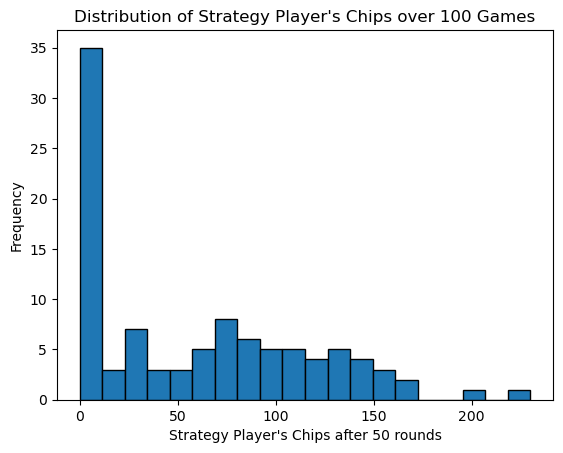

Average chips after 50 rounds: 59.7
Average winnings per round: -0.8059999999999999
Standard deviation of chips: 57.505738844049304
Probability of net winning (>100 chips): 0.25
Probability of net losing (<100 chips): 0.7


In [76]:
import matplotlib.pyplot as plt
import numpy as np

num_games = 100 #number of games to simulate
rounds_per_game = 50
winnings_list = []

suits = ['Club', 'Spade', 'Heart', 'Diamond'] #initializes list of suits and values
values = list(range(1, 14))

for game_idx in range(num_games): #simulates num_games games and stores the final chips of the strategy player after each game in winnings_list
    cards = []
    for _ in range(6):
        for suit in suits:
            for value in values:
                cards.append(card(suit, value))
    cards.append(card('Plastic', 0)) # adds plastic card
    deck1 = deck(cards)
    deck1.shuffle()

    strategy_player = counting_player() #creates a counting player with threshold 0, which is a common simple card counting strategy where you hit if the count is 0 or negative and stay if it's positive
    dealer1 = dealer()
    dealer2 = dealer()
    dealer3 = dealer()
    dealer_main = dealer()

    sim_game = game(deck1, num_games, print_var=0)  #creates a game with the shuffled deck and print_var 0 to suppress output for the simulation
    sim_game.add_player(strategy_player)
    sim_game.add_player(dealer1)
    sim_game.add_player(dealer2)
    sim_game.add_player(dealer3)
    sim_game.add_player(dealer_main)

    rounds = 0 #plays the game repeatedly until rounds_per_game rounds have been played or the strategy player runs out of chips, reshuffling the deck if there are not enough cards to deal a new game, and updating the strategy player's chips based on wins and losses
    while rounds < rounds_per_game and strategy_player.chips > 0:
        if len(deck1._deck__cards) < len(sim_game._game__players) * 5:
            new_cards = []
            for _ in range(6):
                for suit in suits:
                    for value in values:
                        new_cards.append(card(suit, value))
            new_cards.append(card('Plastic', 0))
            deck1 = deck(new_cards)
            deck1.shuffle()
            sim_game._game__deck = deck1

        results = sim_game.play_game(verbose=False)
        for r in results:
            strategy_player.chips += r * 10
        rounds += 1

    winnings_list.append(strategy_player.chips)

winnings_array = np.array(winnings_list) #converts winnings list to numpy array for easier analysis
avg_winnings = np.mean(winnings_array)
std_winnings = np.std(winnings_array)
prob_net_win = np.mean(winnings_array > 100)  # probability chips > starting chips
prob_net_loss = np.mean(winnings_array < 100)  # probability chips < starting chips
avg_per_round = np.mean((winnings_array - 100)/rounds_per_game)  # average winnings per round

plt.hist(winnings_array, bins=20, edgecolor='black') #plots histogram of strategy player's chips after 50 rounds over 100 games
plt.xlabel("Strategy Player's Chips after 50 rounds")
plt.ylabel("Frequency")
plt.title("Distribution of Strategy Player's Chips over 100 Games")
plt.show()

print(f"Average chips after 50 rounds: {avg_winnings}") #prints average chips after 50 rounds, standard deviation of chips, probability of net winning, and probability of net losing
print(f"Average winnings per round: {avg_per_round}")
print(f"Standard deviation of chips: {std_winnings}")
print(f"Probability of net winning (>100 chips): {prob_net_win}")
print(f"Probability of net losing (<100 chips): {prob_net_loss}")

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

Optimal threshold based on average chips: 6

Threshold -2:
 Avg Chips=60.00
 Std=64.22
 Average round=-0.80
 Probability Win=0.22
 Probability Loss=0.75

Threshold 0:
 Avg Chips=63.70
 Std=50.15
 Average round=-0.73
 Probability Win=0.19
 Probability Loss=0.72

Threshold 2:
 Avg Chips=65.70
 Std=57.78
 Average round=-0.69
 Probability Win=0.26
 Probability Loss=0.66

Threshold 4:
 Avg Chips=59.90
 Std=57.18
 Average round=-0.80
 Probability Win=0.23
 Probability Loss=0.73

Threshold 6:
 Avg Chips=68.90
 Std=56.53
 Average round=-0.62
 Probability Win=0.27
 Probability Loss=0.65



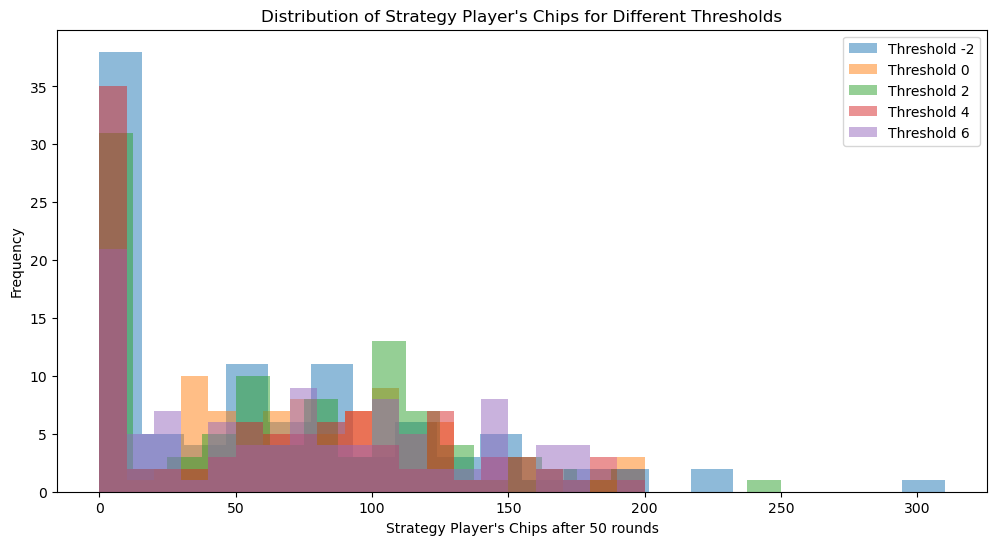

In [81]:
num_games = 100
rounds_per_game = 50
threshold_values = [-2, 0, 2, 4, 6]  # scan at least 5 different threshold values
suits = ['Club', 'Spade', 'Heart', 'Diamond']
values = list(range(1, 14))

results_per_threshold = {}

for threshold in threshold_values: #simulates num_games games for each threshold value and stores the results in a dictionary with the threshold as the key and a dictionary of results as the value
    winnings_list = []

    for game_idx in range(num_games):
        cards = []
        for _ in range(6):
            for suit in suits:
                for value in values:
                    cards.append(card(suit, value))
        cards.append(card('Plastic', 0)) # adds plastic card
        deck1 = deck(cards)
        deck1.shuffle()

        strategy_player = counting_player(threshold=threshold)
        dealer1 = dealer()
        dealer2 = dealer()
        dealer3 = dealer()
        dealer_main = dealer()

        sim_game = game(deck1, num_games=1,print_var=0)
        sim_game.add_player(strategy_player)
        sim_game.add_player(dealer1)
        sim_game.add_player(dealer2)
        sim_game.add_player(dealer3)
        sim_game.add_player(dealer_main)

        rounds = 0
        while rounds < rounds_per_game and strategy_player.chips > 0:
            if len(deck1._deck__cards) < len(sim_game._game__players) * 5:
                new_cards = []
                for _ in range(6):
                    for suit in suits:
                        for value in values:
                            new_cards.append(card(suit, value))
                new_cards.append(card('Plastic', 0))
                deck1 = deck(new_cards)
                deck1.shuffle()
                sim_game._game__deck = deck1

            results = sim_game.play_game(verbose=False)
            for r in results:
                strategy_player.chips += r * 10
            rounds += 1

        winnings_list.append(strategy_player.chips)

    winnings_array = np.array(winnings_list) #converts winnings list to numpy array for easier analysis
    avg_chips = np.mean(winnings_array)
    std_chips = np.std(winnings_array)
    prob_net_win = np.mean(winnings_array > 100)
    prob_net_loss = np.mean(winnings_array < 100)
    avg_per_round = np.mean((winnings_array - 100)/rounds_per_game)

    results_per_threshold[threshold] = { #stores results for this threshold in the results dictionary
        "avg_chips": avg_chips,
        "std_chips": std_chips,
        "prob_win": prob_net_win,
        "prob_loss": prob_net_loss,
        "avg_per_round": avg_per_round,
        "winnings_array": winnings_array
    }

best_threshold = max(results_per_threshold, key=lambda t: results_per_threshold[t]["avg_chips"]) #finds the threshold with the highest average chips after 50 rounds and prints it along with the results for each threshold
print(f"Optimal threshold based on average chips: {best_threshold}\n")

for threshold in threshold_values: #prints results for each threshold
    res = results_per_threshold[threshold]
    print(f"Threshold {threshold}:\n Avg Chips={res['avg_chips']:.2f}\n "
          f"Std={res['std_chips']:.2f}\n Average round={res['avg_per_round']:.2f}\n "
          f"Probability Win={res['prob_win']:.2f}\n Probability Loss={res['prob_loss']:.2f}\n")

plt.figure(figsize=(12, 6)) #plots histograms of the strategy player's chips after 50 rounds for each threshold value on the same plot for comparison
for threshold in threshold_values:
    plt.hist(results_per_threshold[threshold]["winnings_array"], bins=20, alpha=0.5, label=f'Threshold {threshold}')
plt.xlabel("Strategy Player's Chips after 50 rounds")
plt.ylabel("Frequency")
plt.title("Distribution of Strategy Player's Chips for Different Thresholds")
plt.legend()
plt.show()

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

Counting Strategy:
 Average Chips=62.60
 Std=64.31
 Average round=-0.75
 Probability Win=0.23
 Probability Loss=0.70

Conservative Strategy:
 Average Chips=56.50
 Std=61.46
 Average round=-0.87
 Probability Win=0.21
 Probability Loss=0.74



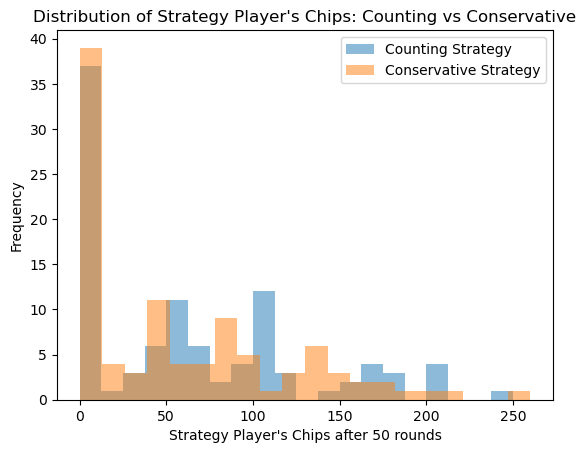

In [80]:
class conservative_player(player): #a simple player that hits until hand value is 12 or more, then stays, which serves as a baseline strategy to compare against the counting player
    def __init__(self):
        super().__init__("Conservative Player")
        self.chips = 100
    
    def decide(self, game):  #conservative player hits until hand value is 12 or more, then stays
        hand_val = game.hand_value(self.hand)
        if hand_val < 12:
            return "hit"
        else:
            return "stay"

num_games = 100 #number of games to simulate for each strategy
rounds_per_game = 50
suits = ['Club', 'Spade', 'Heart', 'Diamond']
values = list(range(1, 14))

results_dict = {} #dictionary to store results for each strategy, with strategy name as key and array of final chips after 50 rounds as value

for strategy_name, player_class in [("Counting", counting_player), ("Conservative", conservative_player)]: #simulates num_games games for each strategy and stores the final chips after 50 rounds in results_dict
    winnings_list = []

    for game_idx in range(num_games): #simulates one game for this strategy
        cards = []
        for _ in range(6):
            for suit in suits:
                for value in values:
                    cards.append(card(suit, value))
        cards.append(card('Plastic', 0))
        deck1 = deck(cards)
        deck1.shuffle()

        strategy_player = player_class() if strategy_name != "Counting" else counting_player(threshold=2) #creates player based on strategy, using threshold 2 for counting player which was found to be optimal in previous analysis
        dealer1 = dealer()
        dealer2 = dealer()
        dealer3 = dealer()
        dealer_main = dealer()

        sim_game = game(deck1, num_games, print_var=0) #creates a game with the shuffled deck and print_var 0 to suppress output for the simulation
        sim_game.add_player(strategy_player)
        sim_game.add_player(dealer1)
        sim_game.add_player(dealer2)
        sim_game.add_player(dealer3)
        sim_game.add_player(dealer_main)

        rounds = 0 #plays the game repeatedly until rounds_per_game rounds have been played or the strategy player runs out of chips, reshuffling the deck if there are not enough cards to deal a new game, and updating the strategy player's chips based on wins and losses
        while rounds < rounds_per_game and strategy_player.chips > 0:
            if len(deck1._deck__cards) < len(sim_game._game__players) * 5:
                new_cards = []
                for _ in range(6):
                    for suit in suits:
                        for value in values:
                            new_cards.append(card(suit, value))
                new_cards.append(card('Plastic', 0))
                deck1 = deck(new_cards)
                deck1.shuffle()
                sim_game._game__deck = deck1

            results = sim_game.play_game(verbose=False) # play a game and get results, which is a list of 1s, 0s, and -1s representing wins, pushes, and losses for the strategy player
            for r in results:
                strategy_player.chips += r * 10
            rounds += 1

        winnings_list.append(strategy_player.chips) #stores the final chips after 50 rounds for this game in the winnings list for this strategy

    results_dict[strategy_name] = np.array(winnings_list) #converts winnings list to numpy array and stores it in results_dict with strategy name as key

for name, chips_array in results_dict.items(): #calculates and prints average chips, standard deviation, average winnings per round, probability of net winning, and probability of net losing for each strategy
    avg_chips = np.mean(chips_array)
    std_chips = np.std(chips_array)
    avg_per_round = np.mean((chips_array - 100)/rounds_per_game)
    prob_win = np.mean(chips_array > 100)
    prob_loss = np.mean(chips_array < 100)
    print(f"{name} Strategy:\n Average Chips={avg_chips:.2f}\n Std={std_chips:.2f}\n "
          f"Average round={avg_per_round:.2f}\n Probability Win={prob_win:.2f}\n Probability Loss={prob_loss:.2f}\n")

plt.hist(results_dict["Counting"], bins=20, alpha=0.5, label="Counting Strategy") #plots histogram of strategy player's chips after 50 rounds for counting strategy
plt.hist(results_dict["Conservative"], bins=20, alpha=0.5, label="Conservative Strategy")
plt.xlabel("Strategy Player's Chips after 50 rounds")
plt.ylabel("Frequency")
plt.title("Distribution of Strategy Player's Chips: Counting vs Conservative")
plt.legend()
plt.show()